# 04 · Which factors are associated with survival?

Compare gender, class, age, and fare using cleaned.csv. Counts and rates answer different questions: rates account for unequal group sizes.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
data = pd.read_csv(root / "data" / "cleaned.csv")
plt.rcParams.update({"figure.figsize": (7, 4), "axes.spines.top": False, "axes.spines.right": False})

## Gender

Compare passenger counts and within-group survival rates.

Survival rate %: {'female': 74.2, 'male': 18.89}
Survived  Did Not Survive  Survived
Sex                                
female                 81       233
male                  468       109


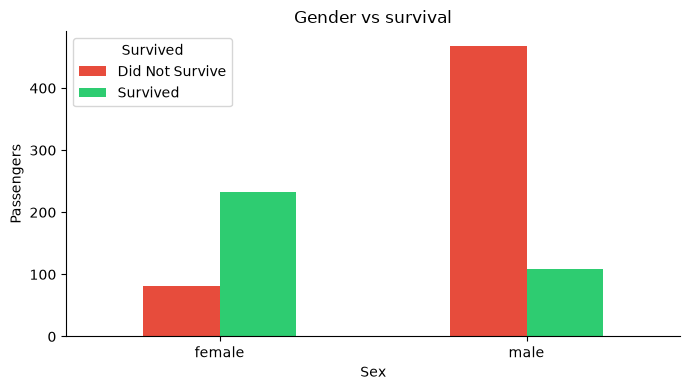

In [2]:
gender = pd.crosstab(data["Sex"], data["Survived"]).reindex(["female", "male"])
print("Survival rate %:", (data.groupby("Sex")["Survived"].mean() * 100).round(2).to_dict())
print(gender.rename(columns={0: "Did Not Survive", 1: "Survived"}))
gender.rename(columns={0: "Did Not Survive", 1: "Survived"}).plot.bar(color=["#e74c3c", "#2ecc71"], rot=0)
plt.title("Gender vs survival")
plt.ylabel("Passengers")
plt.tight_layout()
plt.show()

**Takeaway:** female survival was 74.20%, compared with 18.89% for males; this is the largest observed group contrast.

## Passenger class

Class is ordinal: 1 = first, 2 = second, 3 = third.

Survival rate %: {1: 62.96, 2: 47.28, 3: 24.24}
Survived  Did Not Survive  Survived
Pclass                             
1                      80       136
2                      97        87
3                     372       119


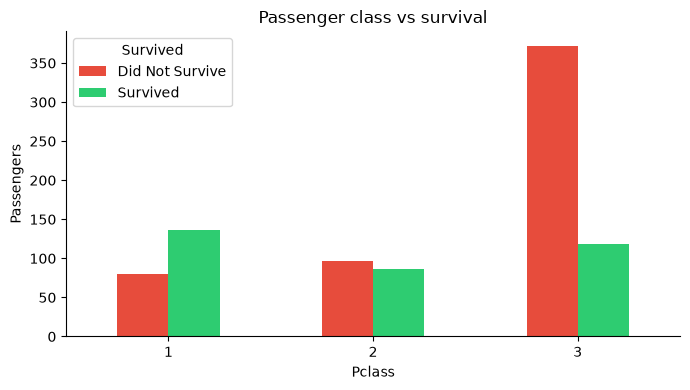

In [3]:
classes = pd.crosstab(data["Pclass"], data["Survived"])
print("Survival rate %:", (data.groupby("Pclass")["Survived"].mean() * 100).round(2).to_dict())
print(classes.rename(columns={0: "Did Not Survive", 1: "Survived"}))
classes.rename(columns={0: "Did Not Survive", 1: "Survived"}).plot.bar(color=["#e74c3c", "#2ecc71"], rot=0)
plt.title("Passenger class vs survival")
plt.ylabel("Passengers")
plt.tight_layout()
plt.show()

**Takeaway:** survival fell from 62.96% in first class to 47.28% in second and 24.24% in third.

## Age

Use decade bins; median-imputed ages are included.

Mean age: {'Did Not Survive': 30.03, 'Survived': 28.29}


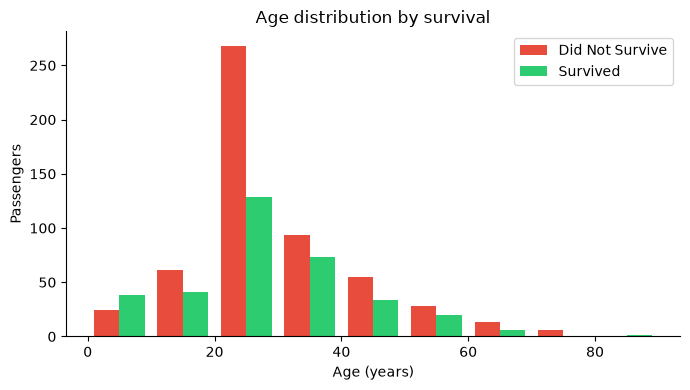

In [4]:
print("Mean age:", data.groupby("Survived")["Age"].mean().round(2).rename(index={0: "Did Not Survive", 1: "Survived"}).to_dict())
plt.hist([data.loc[data["Survived"] == 0, "Age"], data.loc[data["Survived"] == 1, "Age"]],
         bins=list(range(0, 91, 10)), color=["#e74c3c", "#2ecc71"], label=["Did Not Survive", "Survived"])
plt.title("Age distribution by survival")
plt.xlabel("Age (years)")
plt.ylabel("Passengers")
plt.legend()
plt.tight_layout()
plt.show()

**Takeaway:** cleaned mean ages were 28.29 for survivors and 30.03 for non-survivors, a small 1.74-year gap; averages can hide differences among children and adults.

## Fare

A box plot shows the skew and unusually high fares as well as the median.

Fare summary:
                  mean  median  count
Survived                             
Did Not Survive  22.12    10.5    549
Survived         48.40    26.0    342


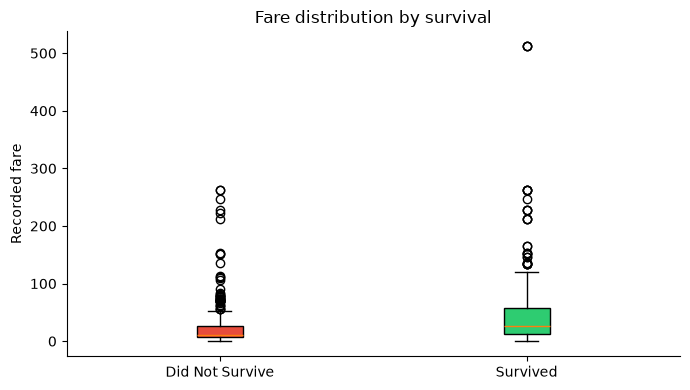

In [5]:
print("Fare summary:")
print(data.groupby("Survived")["Fare"].agg(["mean", "median", "count"]).round(2).rename(index={0: "Did Not Survive", 1: "Survived"}))
boxes = plt.boxplot([data.loc[data["Survived"] == 0, "Fare"], data.loc[data["Survived"] == 1, "Fare"]],
                    tick_labels=["Did Not Survive", "Survived"], patch_artist=True)
for patch, color in zip(boxes["boxes"], ["#e74c3c", "#2ecc71"]):
    patch.set_facecolor(color)
plt.title("Fare distribution by survival")
plt.ylabel("Recorded fare")
plt.tight_layout()
plt.show()

**Takeaway:** survivors paid 48.40 on average versus 22.12 for non-survivors; fare and class overlap, so these are not independent effects.